# Reading biomedical images with `bioio` 🔬

This recipe shows how to read biomedical / microscopy images in Croissant through
[bioio](https://github.com/bioio-devs/bioio). A single umbrella encoding format,
`application/x-bioio`, opts a resource into the bioio reader; bioio then picks the
right plugin from the file itself (CZI, OME-TIFF, OME-Zarr, HDF5, …).

There are 2 main chapters in this notebook:
1. Chapter A: Pythonically bootstrapping Croissant files with local minimal examples or remotely stored files
2. Chapter B: Loading the same Croissant files stored in `croissant/datasets/1.1/bioio_*` and demoed in [reading_bioimages.md](reading_bioimages.md)

# Chapter A: bootstrap Croissant files inside the notebook

Each section below describes a biomedical image with Croissant *programmatically* (building `mlc.Metadata` in Python), then loads it to verify the round-trip. [Chapter B](#Chapter-B-\u2014-load-the-committed-bioio-Croissant-files) re-does this with the JSON-LD files already committed under `datasets/1.1/`.

In [1]:
# Install mlcroissant (with the bioio reader), the CZI plugin and matplotlib.
# Already-installed environments (e.g. a local editable checkout) are left as-is.
try:
    import mlcroissant
    import bioio
    import bioio_czi
    import matplotlib 
except ImportError:
    !pip install "mlcroissant[bioio] @ git+https://github.com/${GITHUB_REPOSITORY:-mlcommons/croissant}.git@${GITHUB_HEAD_REF:-main}#subdirectory=python/mlcroissant"
    !pip install bioio-czi matplotlib

In [2]:
%matplotlib inline
import json
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import requests

import mlcroissant as mlc
from absl import logging as absl_logging

absl_logging.set_verbosity(absl_logging.ERROR)  # quiet validation hints
from mlcroissant._src.structure_graph.nodes.source import FileProperty

WORK = tempfile.mkdtemp()


def bioimage_dataset(folder, includes, name):
    """Build and load a Croissant dataset over local bioimages in `folder`.

    Two FileSets point at the same files: the `images` record set loads the pixel
    array, while the `metadata` record set reads only the headers (no pixels).
    """
    def column(fid, col, dtype):
        return mlc.Field(
            id=fid, name=fid, description=col, data_types=dtype,
            source=mlc.Source(file_set="headers", extract=mlc.Extract(column=col)),
        )

    metadata = mlc.Metadata(
        name=name,
        description="A bioio image example.",
        url="https://github.com/bioio-devs/bioio",
        distribution=[
            mlc.FileSet(id="pixels", name="pixels", description="Pixel content.",
                        encoding_formats=["application/x-bioio"], includes=includes),
            mlc.FileSet(id="headers", name="headers", description="Headers only.",
                        encoding_formats=["application/x-bioio"], includes=includes),
        ],
        record_sets=[
            mlc.RecordSet(id="metadata", name="metadata", fields=[
                column("metadata/dimension_order", "dimension_order", mlc.DataType.TEXT),
                column("metadata/size_x", "size_x", mlc.DataType.INTEGER),
                column("metadata/size_y", "size_y", mlc.DataType.INTEGER),
                column("metadata/size_c", "size_c", mlc.DataType.INTEGER),
                column("metadata/chunk_y", "chunk_y", mlc.DataType.INTEGER),
                column("metadata/chunk_x", "chunk_x", mlc.DataType.INTEGER),
                column("metadata/dtype", "dtype", mlc.DataType.TEXT),
            ]),
            mlc.RecordSet(id="images", name="images", fields=[
                mlc.Field(
                    id="images/content", name="images/content",
                    description="The (T, C, Z, Y, X) pixel array read by bioio.",
                    data_types=mlc.DataType.VIDEO_OBJECT,
                    source=mlc.Source(
                        file_set="pixels",
                        extract=mlc.Extract(file_property=FileProperty.content),
                    ),
                ),
            ]),
        ],
    )
    path = os.path.join(folder, "metadata.json")
    with open(path, "w") as f:
        json.dump(metadata.to_json(), f, indent=2)
    return mlc.Dataset(path)


def first_plane(array):
    """Return the first 2-D (Y, X) plane of an N-D image array, for display."""
    array = np.asarray(array)
    return array.reshape(-1, array.shape[-2], array.shape[-1])[0]

## 1. OME-TIFF

We synthesize a small OME-TIFF (two Gaussian "cells") and describe it with Croissant.

In [3]:
from bioio.writers import OmeTiffWriter

tiff_root = os.path.join(WORK, "ome_tiff")
os.makedirs(os.path.join(tiff_root, "data"), exist_ok=True)

yy, xx = np.mgrid[0:128, 0:128]
def blob(cy, cx, s):
    return np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s ** 2))
image = (4000 * blob(45, 50, 12) + 6000 * blob(85, 90, 18)).astype(np.uint16)
OmeTiffWriter.save(image, os.path.join(tiff_root, "data", "cells_0001.ome.tiff"))

ds = bioimage_dataset(tiff_root, "data/*.ome.tiff", "ome-tiff-demo")

# Metadata only -- no pixels are read here:
print(next(iter(ds.records("metadata"))))

{'metadata/dimension_order': b'TCZYX', 'metadata/size_x': 128, 'metadata/size_y': 128, 'metadata/size_c': 1, 'metadata/chunk_y': 128, 'metadata/chunk_x': 128, 'metadata/dtype': b'uint16'}


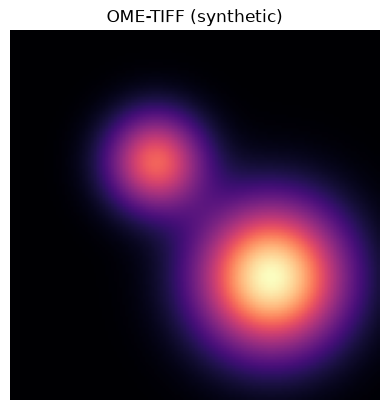

In [4]:
# Now load the pixel array and display it:
record = next(iter(ds.records("images")))
plt.imshow(first_plane(record["images/content"]), cmap="magma")
plt.title("OME-TIFF (synthetic)")
plt.axis("off")
plt.show()

## 2. CZI (ZEISS)

CZI is the native ZEISS microscope format. We download a small sample and read it
with the `bioio-czi` plugin — exactly the same Croissant code as above.

In [5]:
czi_root = os.path.join(WORK, "czi")
os.makedirs(os.path.join(czi_root, "data"), exist_ok=True)
CZI_URL = ("https://github.com/bioio-devs/bioio-czi/raw/main/"
           "bioio_czi/tests/resources/s_1_t_1_c_1_z_1.czi")
response = requests.get(CZI_URL, timeout=60)
response.raise_for_status()
with open(os.path.join(czi_root, "data", "sample.czi"), "wb") as f:
    f.write(response.content)

ds_czi = bioimage_dataset(czi_root, "data/*.czi", "czi-demo")
print(next(iter(ds_czi.records("metadata"))))

{'metadata/dimension_order': b'TCZYX', 'metadata/size_x': 475, 'metadata/size_y': 325, 'metadata/size_c': 1, 'metadata/chunk_y': 325, 'metadata/chunk_x': 475, 'metadata/dtype': b'uint16'}


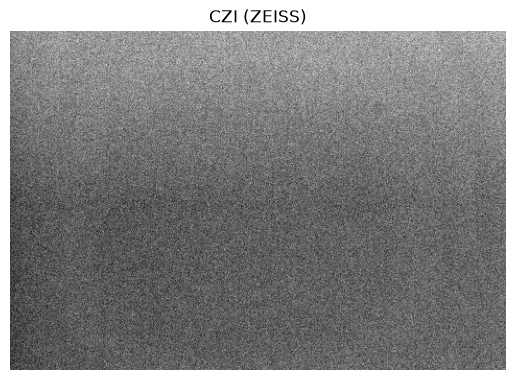

In [6]:
record = next(iter(ds_czi.records("images")))
plt.imshow(first_plane(record["images/content"]), cmap="gray")
plt.title("CZI (ZEISS)")
plt.axis("off")
plt.show()

## 3. OME-Zarr (chunked directory store)

An OME-Zarr image is a *chunked directory* rather than a single file. Croissant
describes it as a `FileObject`, and bioio reads such stores directly. We generate
a small store locally here; bioio reads remote stores (S3/HTTP) the same way.

In [7]:
from bioio import BioImage
from bioio_ome_zarr.writers import OMEZarrWriter

# OME-Zarr is a chunked *directory* store; we generate a small one locally.
zarr_path = os.path.join(WORK, "cells.zarr")
yy, xx = np.mgrid[0:96, 0:96]
def blob(cy, cx, s):
    return np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s ** 2))
volume = np.stack([
    (5000 * blob(35, 40, 10)).astype(np.uint16),
    (8000 * blob(70, 65, 14)).astype(np.uint16),
])[None, :, None]  # (T, C, Z, Y, X)
OMEZarrWriter(
    store=zarr_path, level_shapes=[volume.shape], dtype=volume.dtype,
    chunk_shape=(1, 1, 1, 32, 32),
    axes_names=["t", "c", "z", "y", "x"],
).write_full_volume(volume)

# Croissant describes the store with the umbrella encoding format:
croissant_description = {
    "@type": "cr:FileObject",
    "@id": "zarr-store",
    "name": "cells.zarr",
    "contentUrl": "cells.zarr",
    "encodingFormat": "application/x-bioio",
}
print(json.dumps(croissant_description, indent=2))

# bioio reads the directory store in place:
image = BioImage(zarr_path)
print("dimension_order:", image.dims.order, "| shape:", image.shape,
      "| channels:", [str(c) for c in image.channel_names])

{
  "@type": "cr:FileObject",
  "@id": "zarr-store",
  "name": "cells.zarr",
  "contentUrl": "cells.zarr",
  "encodingFormat": "application/x-bioio"
}
dimension_order: TCZYX | shape: (1, 2, 1, 96, 96) | channels: ['Channel:Image:0', 'Channel:Image:1']


full read: (1, 2, 1, 96, 96) uint16 (37 kB)


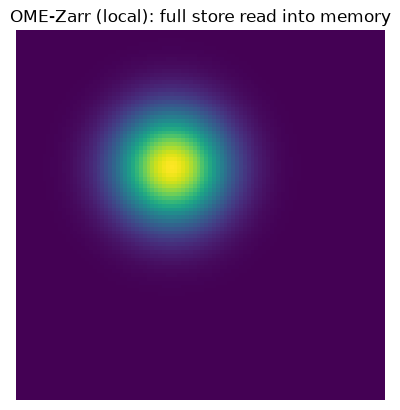

In [8]:
# Read the ENTIRE store into memory (small enough here):
full_image = image.data  # full (T, C, Z, Y, X) array -- every chunk is fetched
print("full read:", full_image.shape, full_image.dtype,
      f"({full_image.nbytes / 1e3:.0f} kB)")
plt.imshow(full_image[0, 0, 0], cmap="viridis")
plt.title("OME-Zarr (local): full store read into memory")
plt.axis("off")
plt.show()

## 4. Chunk-wise reading

Croissant surfaces each image's native chunk shape in the `metadata` record set (`chunk_t/c/z/y/x`), read from the headers without loading pixels. You use it to plan chunk-aligned reads; bioio performs the actual partial I/O.

This is the counterpart to the full read above: when an image is too large to load whole, you read only the chunks you need.

In [9]:
# The chunk shape comes straight from the Croissant `metadata` record set:
meta = next(iter(ds.records("metadata")))
print("OME-TIFF  size (Y, X):", meta["metadata/size_y"], meta["metadata/size_x"])
print("OME-TIFF chunk (Y, X):", meta["metadata/chunk_y"], meta["metadata/chunk_x"])

OME-TIFF  size (Y, X): 128 128
OME-TIFF chunk (Y, X): 128 128


OME-Zarr chunks (Y, X): (96,) (96,)


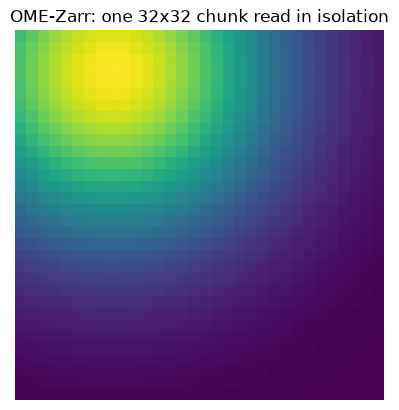

In [10]:
# A chunked store (our OME-Zarr) lets bioio read one tile without the rest:
print("OME-Zarr chunks (Y, X):", image.dask_data.chunks[3], image.dask_data.chunks[4])
tile = image.get_image_dask_data("YX", T=0, C=0, Z=0)[32:64, 32:64].compute()
plt.imshow(tile, cmap="viridis")
plt.title("OME-Zarr: one 32x32 chunk read in isolation")
plt.axis("off")
plt.show()

## 5. Remote OME-Zarr (cloud, multiscale)

Real cloud images are large and **multiscale** (an image pyramid). This Hugging Face store ([`LuciexJune/ome-vip-dataset`](https://huggingface.co/datasets/LuciexJune/ome-vip-dataset)) has several levels: level 0 is full resolution (1937\u00d72048\u00d72048 \u2248 16 GB), and each higher level is the **whole image downsampled**.

Reading the full-resolution volume means fetching *every* chunk \u2014 thousands of HTTP requests, which cloud hosts often rate-limit \u2014 so you read a coarse pyramid level for an overview, or stream chunk-aligned regions (\u00a74) for full-res detail. Here we read the **whole image at a coarse level**.

> Remote reads need network access and CA certificates; the cell degrades gracefully if it can't connect.

{
  "@type": "cr:FileObject",
  "@id": "zarr-store",
  "name": "ome-vip-dataset",
  "contentUrl": "https://huggingface.co/datasets/LuciexJune/ome-vip-dataset/resolve/main",
  "encodingFormat": "application/x-bioio"
}


pyramid levels: (0, 1, 2, 3, 4, 5)
full-res (level 0): (1, 1, 1937, 2048, 2048) ~ 16.2 GB -- too big to read whole


level 3 (whole image, one Z-slice): (256, 256)


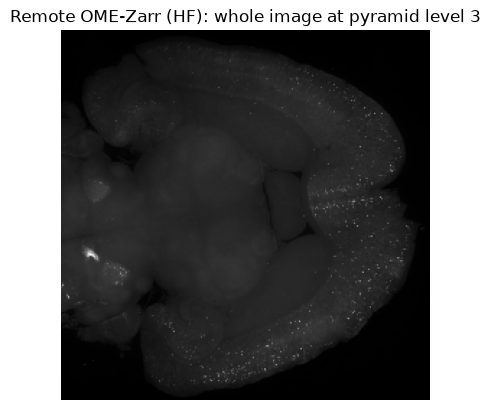

In [11]:
import logging
import os
import certifi
import bioio_ome_zarr

# bioio reads remote OME-Zarr via zarr -> fsspec -> aiohttp. On installs where
# aiohttp's default SSL context can't verify the host (e.g. macOS python.org
# Pythons that lack a system CA store), the call below would fail with a wrapped
# UnsupportedFileFormatError. Point both stdlib SSL and aiohttp at certifi's
# bundle -- the same one `requests` uses -- so they agree.
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())

REMOTE_ZARR = "https://huggingface.co/datasets/LuciexJune/ome-vip-dataset/resolve/main"

# Croissant describes the remote store with the umbrella format:
print(json.dumps({
    "@type": "cr:FileObject", "@id": "zarr-store", "name": "ome-vip-dataset",
    "contentUrl": REMOTE_ZARR, "encodingFormat": "application/x-bioio",
}, indent=2))

bioio_logger = logging.getLogger("bioio")
prev_level = bioio_logger.level
bioio_logger.setLevel(logging.ERROR)
try:
    # HF serves the store over plain HTTP (no `.zarr` suffix / no directory
    # listing), so we point bioio at the OME-Zarr reader explicitly.
    remote = BioImage(REMOTE_ZARR, reader=bioio_ome_zarr.Reader)
    gb = np.prod(remote.shape) * remote.dtype.itemsize / 1e9
    print("pyramid levels:", remote.resolution_levels)
    print(f"full-res (level 0): {remote.shape} ~ {gb:.1f} GB -- too big to read whole")
    # Read the WHOLE image at a coarse pyramid level (a downsampled overview):
    remote.set_resolution_level(3)
    whole = remote.get_image_dask_data("YX", T=0, C=0, Z=remote.dims.Z // 2).compute()
    print("level 3 (whole image, one Z-slice):", whole.shape)
    plt.imshow(whole, cmap="gray")
    plt.title("Remote OME-Zarr (HF): whole image at pyramid level 3")
    plt.axis("off")
    plt.show()
except Exception as exc:
    # bioio wraps the underlying issue in UnsupportedFileFormatError; surface the
    # root cause so the user sees what actually failed (SSL, DNS, 429, ...).
    root = exc
    while root.__cause__ is not None or root.__context__ is not None:
        root = root.__cause__ or root.__context__
    print(f"Remote read skipped -- {type(exc).__name__}")
    print(f"  underlying cause ({type(root).__name__}): {str(root)[:240]}")
finally:
    bioio_logger.setLevel(prev_level)

## 6. Remote OME-Zarr through Croissant (download + extract)

An OME-Zarr is a *directory*, so it can't be fetched as a single remote file. But when it's shipped as a `.zip`/`.tar` (common on Zenodo), Croissant downloads and extracts it and bioio reads the nested image \u2014 the whole pipeline, no manual steps. This [Zenodo OME-NGFF plate](https://zenodo.org/records/13305156) (CC-BY-4.0) is a `.zip`; as an HCS plate its image lives in a well/field subgroup (`B/03/0`). We read just the headers (no pixels).

> Needs network access and CA certificates; the cell degrades gracefully otherwise.

In [12]:
STORE = "20200812-CardiomyocyteDifferentiation14-Cycle1.zarr"
ZIP_URL = f"https://zenodo.org/records/13305156/files/{STORE}.zip"

def _meta_field(name, dtype):
    return mlc.Field(
        id=f"metadata/{name}", name=f"metadata/{name}", description=name,
        data_types=dtype,
        source=mlc.Source(file_object="well-B03", extract=mlc.Extract(column=name)),
    )

remote = mlc.Metadata(
    name="cardiomyocyte-ome-zarr",
    description="Remote OME-Zarr (HCS plate) loaded via Croissant.",
    url="https://zenodo.org/records/13305156",
    distribution=[
        # The store is shipped as a single .zip -- Croissant downloads + extracts it:
        mlc.FileObject(id="data-zip", name=f"{STORE}.zip", content_url=ZIP_URL,
                       encoding_formats=["application/zip"],
                       md5="efc21fe8d4ea3abab76226d8c166452c"),
        # The image is a well/field subgroup inside the extracted store:
        mlc.FileObject(id="well-B03", name="well B/03 field 0", contained_in=["data-zip"],
                       content_url=f"{STORE}/B/03/0", encoding_formats=["application/x-bioio"]),
    ],
    record_sets=[mlc.RecordSet(id="metadata", name="metadata", fields=[
        _meta_field("dimension_order", mlc.DataType.TEXT),
        _meta_field("size_x", mlc.DataType.INTEGER),
        _meta_field("size_y", mlc.DataType.INTEGER),
        _meta_field("size_z", mlc.DataType.INTEGER),
        _meta_field("chunk_y", mlc.DataType.INTEGER),
        _meta_field("chunk_x", mlc.DataType.INTEGER),
        # FileProperty.filepath surfaces the on-disk path that Croissant resolved to
        # (i.e. the extracted nested zarr group), so the cell below can display it.
        mlc.Field(
            id="metadata/path", name="metadata/path", description="extracted on-disk path",
            data_types=mlc.DataType.TEXT,
            source=mlc.Source(
                file_object="well-B03",
                extract=mlc.Extract(file_property=FileProperty.filepath),
            ),
        ),
    ])],
)

meta_path = os.path.join(WORK, "cardiomyocyte.json")
with open(meta_path, "w") as fh:
    json.dump(remote.to_json(), fh)

cardio_record = None
try:
    cardio_record = next(iter(mlc.Dataset(meta_path).records("metadata")))
    print("Croissant downloaded the zip, extracted it, and read the nested OME-Zarr:")
    for key, value in cardio_record.items():
        if key == "metadata/path":  # skip in the printed summary -- long cache path
            continue
        print(f"  {key}: {value.decode() if isinstance(value, bytes) else value}")
except Exception as exc:
    print("Skipped (needs network + CA certificates):", type(exc).__name__)

Croissant downloaded the zip, extracted it, and read the nested OME-Zarr:
  metadata/dimension_order: TCZYX
  metadata/size_x: 5120
  metadata/size_y: 2160
  metadata/size_z: 2
  metadata/chunk_y: 2160
  metadata/chunk_x: 2560


displaying coarsest pyramid level 4: (135, 320)


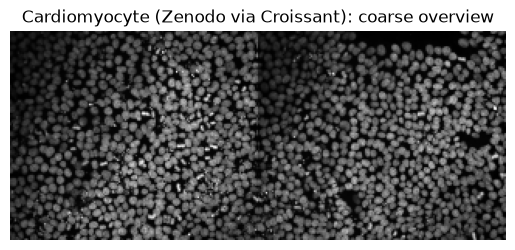

In [13]:
# Display the image: open the extracted path bioio resolved during the load above
# and show a downsampled overview (the full-res plane is 2160 x 5120).
if cardio_record is None:
    print("Skipped (remote load did not complete).")
else:
    import bioio_ome_zarr  # nested/suffix-less group needs the reader specified
    cardio_path = cardio_record["metadata/path"]
    cardio_path = cardio_path.decode() if isinstance(cardio_path, bytes) else cardio_path
    cardio_img = BioImage(cardio_path, reader=bioio_ome_zarr.Reader)
    cardio_img.set_resolution_level(cardio_img.resolution_levels[-1])  # coarsest
    plane = cardio_img.get_image_dask_data("YX", T=0, C=0, Z=0).compute()
    print(f"displaying coarsest pyramid level {cardio_img.resolution_levels[-1]}:", plane.shape)
    plt.imshow(plane, cmap="gray")
    plt.title("Cardiomyocyte (Zenodo via Croissant): coarse overview")
    plt.axis("off")
    plt.show()

# Chapter B:  load the committed bioio Croissant files

The runbook ([reading_bioimages.md](reading_bioimages.md)) shows the CLI usage (`mlcroissant load --jsonld ...`). The same loads work through the Python API via `mlc.Dataset(path).records(record_set=...)` \u2014 demonstrated below for each of the bioio example datasets shipped under `datasets/1.1/`.

In [14]:
import pathlib

def _find_datasets_dir():
    """Find datasets/1.1/ in the current repo, regardless of cwd."""
    for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        candidate = parent / "datasets" / "1.1"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("Could not find datasets/1.1/ from cwd.")

DATASETS_DIR = _find_datasets_dir()
print("datasets root:", DATASETS_DIR)
print("available bioio examples:", sorted(p.name for p in DATASETS_DIR.glob("bioio-*")))

datasets root: /Users/steffen/Documents/croissant/datasets/1.1
available bioio examples: ['bioio-avi', 'bioio-czi', 'bioio-hdf5', 'bioio-ome-tiff', 'bioio-ome-zarr-cardiomyocyte', 'bioio-ome-zarr-hf']


## 7. `bioio-ome-tiff` (hermetic, local data)

The hermetic example: the OME-TIFF files live under `datasets/1.1/bioio-ome-tiff/data/`, so this works offline. Reads metadata and pixels through the *committed* Croissant file (no inline construction).

metadata record set:
  {'metadata/filename': 'synthetic_blob_0001.ome.tiff', 'metadata/dimension_order': 'TCZYX', 'metadata/size_x': 64, 'metadata/size_y': 64, 'metadata/size_c': 1, 'metadata/dtype': 'uint8', 'metadata/chunk_z': 1, 'metadata/chunk_y': 64, 'metadata/chunk_x': 64}
  {'metadata/filename': 'synthetic_blob_0002.ome.tiff', 'metadata/dimension_order': 'TCZYX', 'metadata/size_x': 64, 'metadata/size_y': 64, 'metadata/size_c': 1, 'metadata/dtype': 'uint8', 'metadata/chunk_z': 1, 'metadata/chunk_y': 64, 'metadata/chunk_x': 64}


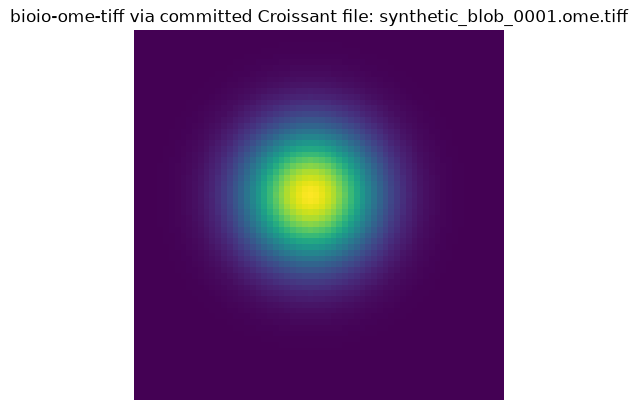

In [15]:
ome_tiff_path = DATASETS_DIR / "bioio-ome-tiff" / "metadata.json"
ome_tiff = mlc.Dataset(str(ome_tiff_path))

# Metadata record set: headers only, no pixels.
print("metadata record set:")
for rec in ome_tiff.records(record_set="metadata"):
    print(" ", {k: (v.decode() if isinstance(v, bytes) else v) for k, v in rec.items()})

# Images record set: bioio loads the pixel array; display the first one.
first = next(iter(ome_tiff.records(record_set="images")))
filename = first["images/image_filename"]
filename = filename.decode() if isinstance(filename, bytes) else filename
plt.imshow(first["images/image_content"][0, 0, 0], cmap="viridis")
plt.title(f"bioio-ome-tiff via committed Croissant file: {filename}")
plt.axis("off")
plt.show()

## 8. `bioio-ome-zarr-cardiomyocyte` (Zenodo .zip, loads end-to-end)

This Croissant file points at a remote `.zip` on Zenodo. Loading it triggers the full pipeline \u2014 download \u2192 extract \u2192 read the nested OME-Zarr group \u2014 just like in [section 6](#6.-Remote-OME-Zarr-through-Croissant-(download-+-extract)), but here the description comes from the committed JSON-LD file rather than being constructed inline.

We augment the committed metadata in-memory with one extra field (`filepath`) so we can locate the extracted store on disk to display the image.

Croissant downloaded the zip, extracted it, and read the nested OME-Zarr:
  metadata/dimension_order: TCZYX
  metadata/size_x: 5120
  metadata/size_y: 2160
  metadata/size_z: 2
  metadata/size_c: 1
  metadata/chunk_z: 1
  metadata/chunk_y: 2160
  metadata/chunk_x: 2560
  metadata/dtype: uint16


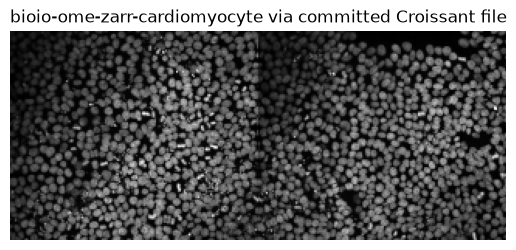

In [16]:
cardio_path = DATASETS_DIR / "bioio-ome-zarr-cardiomyocyte" / "metadata.json"
cardio_jsonld = json.loads(cardio_path.read_text())
# Add a transient `filepath` field so we can open the extracted store with bioio.
cardio_jsonld["recordSet"][0]["field"].append({
    "@type": "cr:Field", "@id": "metadata/path", "name": "metadata/path",
    "description": "Extracted on-disk path of the OME-Zarr store.",
    "dataType": "sc:Text",
    "source": {"fileObject": {"@id": "well-B03"},
               "extract": {"fileProperty": "filepath"}},
})

try:
    cardio_record = next(iter(mlc.Dataset(cardio_jsonld).records(record_set="metadata")))
    print("Croissant downloaded the zip, extracted it, and read the nested OME-Zarr:")
    for key, value in cardio_record.items():
        if key == "metadata/path":
            continue
        print(f"  {key}: {value.decode() if isinstance(value, bytes) else value}")

    # Display: open the resolved extracted path with bioio at a coarse pyramid level.
    import bioio_ome_zarr  # nested/suffix-less group: specify the reader
    path = cardio_record["metadata/path"]
    path = path.decode() if isinstance(path, bytes) else str(path)
    img = BioImage(path, reader=bioio_ome_zarr.Reader)
    img.set_resolution_level(img.resolution_levels[-1])
    plane = img.get_image_dask_data("YX", T=0, C=0, Z=0).compute()
    plt.imshow(plane, cmap="gray")
    plt.title("bioio-ome-zarr-cardiomyocyte via committed Croissant file")
    plt.axis("off")
    plt.show()
except Exception as exc:
    print(f"Skipped ({type(exc).__name__}): needs network access.")

## 9. Describe-only datasets (CZI, OME-Zarr HF, HDF5/Imaris, AVI)

The remaining four files *describe* live single-file resources. Croissant validates and constructs them through the Python API; reading pixels through Croissant currently needs the matching plugin and is constrained by the download-cache extension stripping noted in the runbook \u2014 these datasets are catalog entries, not loadable pipelines (yet).

Chapter A above shows how to actually *read* CZI and remote OME-Zarr.

In [17]:
describe_only = ["bioio-czi", "bioio-ome-zarr-hf", "bioio-hdf5", "bioio-avi"]
for name in describe_only:
    md = mlc.Dataset(str(DATASETS_DIR / name / "metadata.json")).metadata.to_json()
    print(f"\n[{name}]")
    print(f"  name:     {md.get('name')}")
    print(f"  url:      {md.get('url')}")
    print(f"  license:  {md.get('license')}")
    keywords = md.get("keywords") or []
    print(f"  keywords: {', '.join(keywords[:5])}")
    print(f"  files:    {len(md.get('distribution', []))}")


[bioio-czi]
  name:     bioio-czi
  url:      https://downloads.openmicroscopy.org/images/Zeiss-CZI/
  license:  https://creativecommons.org/licenses/by/4.0/
  keywords: bioio, CZI, ZEISS, microscopy, biomedical
  files:    1

[bioio-ome-zarr-hf]
  name:     bioio-ome-zarr-hf
  url:      https://huggingface.co/datasets/LuciexJune/ome-vip-dataset
  license:  https://www.apache.org/licenses/LICENSE-2.0
  keywords: bioio, OME-Zarr, OME-NGFF, microscopy, biomedical
  files:    1

[bioio-hdf5]
  name:     bioio-hdf5
  url:      https://downloads.openmicroscopy.org/images/Imaris-IMS/
  license:  https://creativecommons.org/licenses/by/4.0/
  keywords: bioio, HDF5, Imaris, microscopy, biomedical
  files:    1

[bioio-avi]
  name:     bioio-avi
  url:      https://archive.org/details/SampleVideo1280x7205mb
  license:  https://creativecommons.org/publicdomain/zero/1.0/
  keywords: bioio, AVI, video, time-lapse
  files:    1


## Summary

- One umbrella encoding format (`application/x-bioio`) routes any biomedical image
  to bioio, which selects the concrete reader itself.
- Reading **metadata is cheap**: the `metadata` record set never loads pixels.
- The **same Croissant code** reads OME-TIFF, CZI and other single-file formats;
  directory stores like OME-Zarr are read in place by bioio.
- Directory stores (OME-Zarr) shipped as a `.zip`/`.tar` load through Croissant end-to-end (download \u2192 extract \u2192 read the nested image).
- `chunk_*` metadata lets callers plan chunk-aligned reads; bioio does the partial I/O (finest for chunked formats like OME-Zarr).
- Formats with no native plugin can use the Bio-Formats fallback
  (`pip install mlcroissant[bioformats]`, requires Java).